# Derivation of Line-of-Sight Velocity for STANAG 4607 Single Dwell

## **Given:**
- **Target:**
  - Position: $(x_t, y_t)$
  - Heading: $\theta_t$ (angle from x-axis)
  - Speed: $v_t$
- **Sensor:**
  - Position: $(x_s, y_s, z_s)$ (altitude $z_s$, nadir at $(x_s, y_s)$)

Assumptions:
- Cartesian plane for ground (x-y).
- LOS velocity is the **projection of target velocity onto the sensor-to-target LOS vector**.

---

## **Step 1: Target Velocity Vector**
Heading $\theta_t$ gives direction:
$$
\mathbf{v_t} = v_t \begin{bmatrix} \cos\theta_t \ \sin\theta_t \ 0 \end{bmatrix}
$$

---

## **Step 2: LOS Vector**
Sensor to target:
$$
\mathbf{r} = \begin{bmatrix} x_t - x_s \ y_t - y_s \ 0 - z_s \end{bmatrix}
$$

LOS unit vector:
$$
\hat{\mathbf{r}} = \frac{\mathbf{r}}{\|\mathbf{r}\|} = \frac{\begin{bmatrix} x_t - x_s \ y_t - y_s \ -z_s \end{bmatrix}}{\sqrt{(x_t - x_s)^2 + (y_t - y_s)^2 + z_s^2}}
$$

---

## **Step 3: LOS Velocity**
LOS velocity is the dot product of target velocity and LOS unit vector:
$$
v_{\text{LOS}} = \mathbf{v_t} \cdot \hat{\mathbf{r}}
$$

Compute:
$$
v_{\text{LOS}} = v_t \begin{bmatrix} \cos\theta_t \ \sin\theta_t \ 0 \end{bmatrix} \cdot \frac{\begin{bmatrix} x_t - x_s \ y_t - y_s \ -z_s \end{bmatrix}}{\sqrt{(x_t - x_s)^2 + (y_t - y_s)^2 + z_s^2}}
$$

So:
$$
\boxed{
v_{\text{LOS}} = v_t \frac{(x_t - x_s)\cos\theta_t + (y_t - y_s)\sin\theta_t}{\sqrt{(x_t - x_s)^2 + (y_t - y_s)^2 + z_s^2}}
}
$$

---

### **Interpretation**
- The numerator is the projection of the target’s velocity onto the ground component of the LOS.
- The denominator normalizes by the full 3D LOS distance.

✅ This matches STANAG 4607 logic for radial velocity in a single dwell.

In [2]:
import math
import numpy as np

def calculate_los_velocity(x_t, y_t, theta_t, v_t, x_s, y_s, z_s):
    """
    Calculate Line-of-Sight (LOS) velocity based on STANAG 4607 single dwell geometry.

    Parameters:
    x_t, y_t : float
        Target position coordinates.
    theta_t : float
        Target heading in radians (angle from x-axis).
    v_t : float
        Target speed.
    x_s, y_s, z_s : float
        Sensor position coordinates (z_s is altitude).

    Returns:
    float
        LOS velocity.
    """
    # Compute differences
    dx = x_t - x_s
    dy = y_t - y_s

    # Compute LOS distance
    los_distance = np.sqrt(dx**2 + dy**2 + z_s**2)

    # Compute LOS velocity using derived formula
    v_los = v_t * ((dx * np.cos(theta_t)) + (dy * np.sin(theta_t))) / los_distance

    return v_los

# Example usage:
# Target at (1000, 500), heading 45 degrees, speed 50 m/s
# Sensor at (0, 0) with altitude 1000 m
# x_t, y_t = 1000, 500
# theta_t = math.radians(45)  # convert degrees to radians
# v_t = 50
# x_s, y_s, z_s = 0, 0, 1000

#los_velocity = calculate_los_velocity(x_t, y_t, theta_t, v_t, x_s, y_s, z_s)
#print(f"LOS Velocity: {los_velocity:.3f} m/s")


In [ ]:
import numpy as np
import pandas as pd

# ---------------------------
# Simulation parameters
# ---------------------------
PLANE_SIZE = 5000.0  # meters (square plane: 0..5000 in both x and y)
N_BACKGROUND = 1000
N_GROUPS = 2
POINTS_PER_GROUP = 10
POINT_SPACING = 100.0  # meters
#LOS_MIN, LOS_MAX = -50.0, 50.0  # m/s
V_TARGET_MIN, V_TARGET_MAX = 5.0, 25.0 # m/s


# Fixed sensor (single dwell)
x_sensor = 0.0
y_sensor = 0.0
z_sensor = 1000.0

# Reproducibility
rng = np.random.default_rng(20251112)

# ---------------------------
# Background points (label = 0)
# ---------------------------
# Uniformly distributed across the plane [0, 5000] x [0, 5000]
background_x = rng.uniform(0.0, PLANE_SIZE, N_BACKGROUND)
background_y = rng.uniform(0.0, PLANE_SIZE, N_BACKGROUND)
background_v = rng.uniform(V_TARGET_MIN, V_TARGET_MAX, N_BACKGROUND)
background_label = np.zeros(N_BACKGROUND, dtype=int)
#background_heading = np.full(N_BACKGROUND, rng.uniform(0.0, 359.9))
background_heading = rng.uniform(0.0, 359.9, size=N_BACKGROUND)
background_hdg_rad = np.deg2rad(background_heading)

x_t = background_x
y_t = background_y
#theta_t = np.radians(background_hdg_rad)
theta_t = background_hdg_rad
v_t = background_v
x_s = x_sensor
y_s = y_sensor
z_s = z_sensor
background_los_vel = calculate_los_velocity(x_t, y_t, theta_t, v_t, x_s, y_s, z_s)


# ---------------------------
# Line group points (label = 1)
# ---------------------------
# Each group: 10 points along a line, spaced 10 m, single LOS velocity per group,
# heading uniformly in [0, 360) degrees. Ensure points remain within the plane by
# sampling group centers within a 45 m margin on all sides.

t_values = (np.arange(POINTS_PER_GROUP) - (POINTS_PER_GROUP - 1)/2.0) * POINT_SPACING  # centered offsets
half_extent = (POINTS_PER_GROUP - 1) * POINT_SPACING / 2.0  # 45 m for 10 points at 10 m spacing

line_x_all = []
line_y_all = []
line_v_all = []
line_label_all = []
heading_deg_all = []
v_group_all = []

for _ in range(N_GROUPS):
    # Heading in radians
    heading_deg = rng.uniform(0.0, 359.9)
    heading_rad = np.deg2rad(heading_deg)
    ux, uy = np.cos(heading_rad), np.sin(heading_rad)

    # Group center sampled with a fixed margin so all points stay within [0, PLANE_SIZE]
    margin = half_extent  # safe for any angle since |ux|, |uy| <= 1
    cx = rng.uniform(margin, PLANE_SIZE - margin)
    cy = rng.uniform(margin, PLANE_SIZE - margin)

    # Points for this group
    x_line = cx + t_values * ux
    y_line = cy + t_values * uy

    # Single target velocity for the group
    #v_group = rng.uniform(LOS_MIN, LOS_MAX)
    v_group = np.full(POINTS_PER_GROUP, rng.uniform(V_TARGET_MIN, V_TARGET_MAX))
    #v_line = np.full(POINTS_PER_GROUP, v_group)
    x_t = x_line
    y_t = y_line
    theta_t = heading_rad  # target heading in radians
    v_t = v_group
    x_s = x_sensor
    y_s = y_sensor
    z_s = z_sensor
    v_line = calculate_los_velocity(x_t, y_t, theta_t, v_t, x_s, y_s, z_s)

    # Collect
    line_x_all.append(x_line)
    line_y_all.append(y_line)
    line_v_all.append(v_line)
    line_label_all.append(np.ones(POINTS_PER_GROUP, dtype=int))
    heading_deg_all.append(np.full(POINTS_PER_GROUP, heading_deg))
    v_group_all.append(np.full(POINTS_PER_GROUP, v_group))

    pass


    

# Concatenate group arrays
line_x_all = np.concatenate(line_x_all)
line_y_all = np.concatenate(line_y_all)
line_v_all = np.concatenate(line_v_all)
line_label_all = np.concatenate(line_label_all)
heading_deg_all = np.concatenate(heading_deg_all)
v_group_all = np.concatenate(v_group_all)

# ---------------------------
# Assemble full DataFrame
# ---------------------------
# Sensor columns repeat per row
n_total = N_BACKGROUND + N_GROUPS * POINTS_PER_GROUP
x_sensor_col = np.full(n_total, x_sensor)
y_sensor_col = np.full(n_total, y_sensor)
z_sensor_col = np.full(n_total, z_sensor)

# Targets
x_target_all = np.concatenate([background_x, line_x_all])
y_target_all = np.concatenate([background_y, line_y_all])
los_all = np.concatenate([background_los_vel, line_v_all])
label_all = np.concatenate([background_label, line_label_all])
heading_all = np.concatenate([background_heading, heading_deg_all])
velocity_all = np.concatenate([background_v, v_group_all])

# Build DataFrame with required column order
cols = [
    'x_sensor', 'y_sensor', 'z_sensor',
    'x_target', 'y_target', 'LOS_Velocity', 'label', 'heading_deg', 'velocity'
]

df = pd.DataFrame({
    'x_sensor': x_sensor_col,
    'y_sensor': y_sensor_col,
    'z_sensor': z_sensor_col,
    'x_target': x_target_all,
    'y_target': y_target_all,
    'LOS_Velocity': los_all,
    'label': label_all,
    'heading_deg': heading_all,
    'velocity': velocity_all,
})[cols]

# ---------------------------
# Save CSV
# ---------------------------
# We cannot write to your Windows OneDrive path from this environment.
# We'll save the file locally with the same filename so you can download/move it.
local_filename = 'C:/Users/charlie.burgwardt/OneDrive - NV5/GMTI/Data/test_sim.csv'  
df.to_csv(local_filename, index=False)


#print(df.head().to_string(index=False))

In [4]:
df.head()



,x_sensor,y_sensor,z_sensor,x_target,y_target,LOS_Velocity,label,heading_deg
0,0.0,0.0,1000.0,4384.178627,1747.443501,24.121988,0,66.667411
1,0.0,0.0,1000.0,3786.754179,4598.484293,19.763282,0,170.566615
2,0.0,0.0,1000.0,473.061422,2240.930837,11.708368,0,124.886608
3,0.0,0.0,1000.0,1042.941141,3348.939693,8.686189,0,181.948538
4,0.0,0.0,1000.0,1382.187563,1887.916081,8.056836,0,274.976270


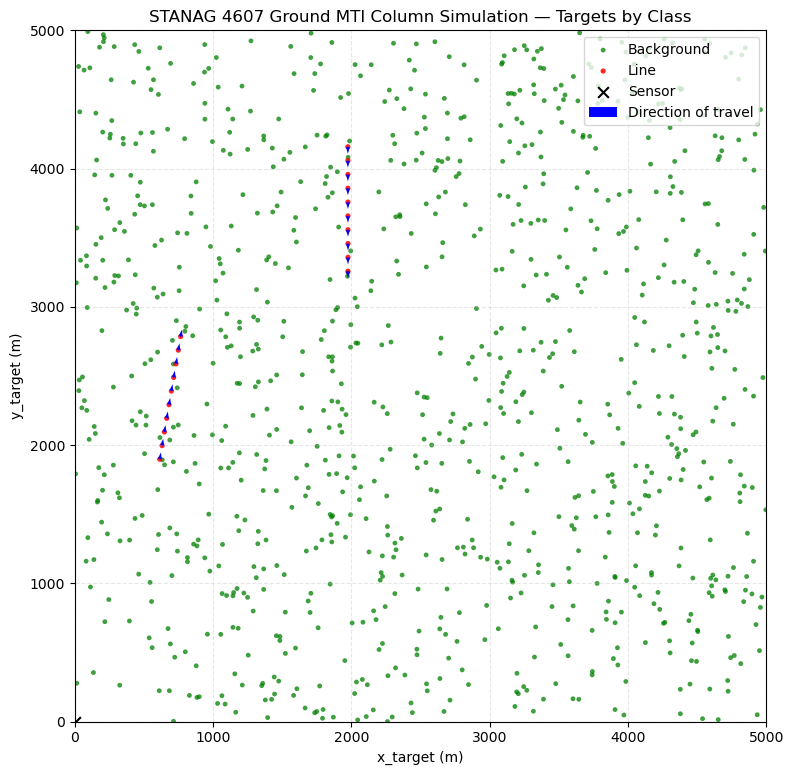

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Option A: if df already exists from the simulation step, skip the next two lines ---
# csv_path = r"C:/Users/charlie.burgwardt/OneDrive - NV5/GMTI/Data/simulatio_1.csv"
# df = pd.read_csv(csv_path)

# Separate classes
bg = df[df['label'] == 0]   # background points (green)
ln = df[df['label'] == 1]   # line-group points (red)

# Create figure
plt.figure(figsize=(8, 8))

# Plot targets
plt.scatter(bg['x_target'], bg['y_target'], s=12, c='green', alpha=0.75, edgecolors='none', label='Background')
plt.scatter(ln['x_target'], ln['y_target'], s=14, c='red',   alpha=0.85, edgecolors='none', label='Line')

# Plot the (fixed) sensor position as a reference
# (All rows have the same sensor position; we can read from the first row)
xs, ys = float(df['x_sensor'].iloc[0]), float(df['y_sensor'].iloc[0])
plt.scatter([xs], [ys], s=60, c='black', marker='x', label='Sensor')

import numpy as np

# Compute arrow components for line-group points
arrow_length = 50  # adjust for visibility (in meters)
angles_rad = np.deg2rad(ln['heading_deg'])  # convert degrees to radians
u = arrow_length * np.cos(angles_rad)  # x-component
v = arrow_length * np.sin(angles_rad)  # y-component

# Plot arrows
plt.quiver(
    ln['x_target'], ln['y_target'],  # starting points
    u, v,                             # direction components
    angles='xy', scale_units='xy', scale=1, color='blue', width=0.003,
    label='Direction of travel'
)

# Cosmetics
plt.gca().set_aspect('equal', 'box')
plt.xlim(0, 5000)
plt.ylim(0, 5000)
plt.xlabel('x_target (m)')
plt.ylabel('y_target (m)')
plt.title('STANAG 4607 Ground MTI Column Simulation — Targets by Class')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', frameon=True)

plt.tight_layout()
